In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
import string
from nltk import pos_tag
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from nltk.util import ngrams
from nltk.text import Text
from collections import Counter

In [38]:
df=pd.read_csv('fake_reviews_dataset.csv')
df

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...
...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ..."
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...


--- ANALISIS DESKRIPTIF 1 ---

### Beberapa Record Dataset Awal :
| category           |   rating | label   | text_                                                                                 |
|:-------------------|---------:|:--------|:--------------------------------------------------------------------------------------|
| Home_and_Kitchen_5 |        5 | CG      | Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty           |
| Home_and_Kitchen_5 |        5 | CG      | love it, a great upgrade from the original.  I've had mine for a couple of years      |
| Home_and_Kitchen_5 |        5 | CG      | This pillow saved my back. I love the look and feel of this pillow.                   |
| Home_and_Kitchen_5 |        1 | CG      | Missing information on how to use it, but it is a great product for the price!  I     |
| Home_and_Kitchen_5 |        5 | CG      | Very nice set. Good quality. We have had the set for two months now and have not been |

### Infor

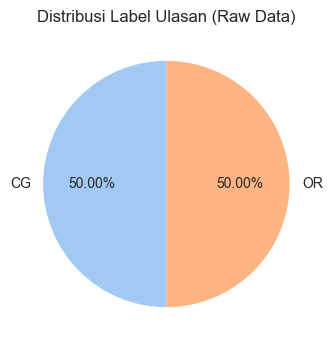

C:\Users\aqiel\AppData\Local\Temp\ipykernel_6644\3920844978.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', palette='tab10')


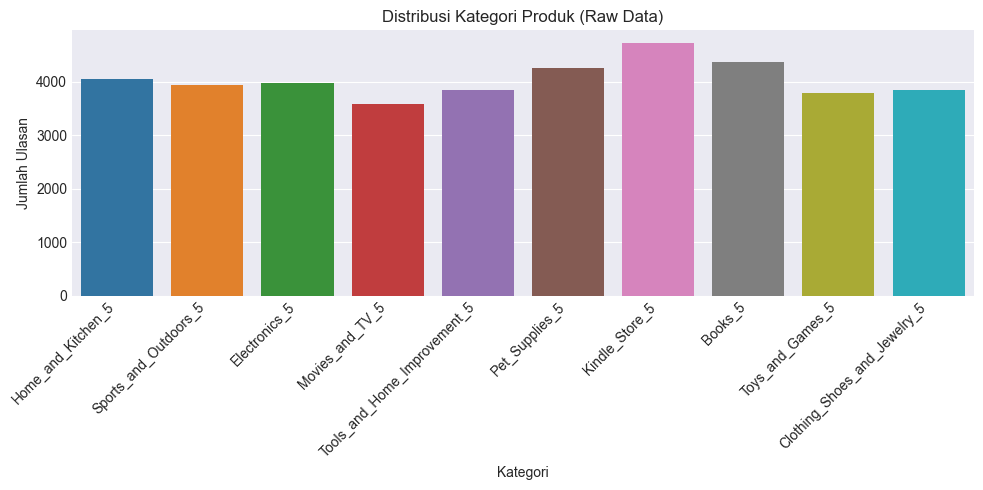

In [39]:
print("--- ANALISIS DESKRIPTIF 1 ---")
print("==================================================================")

print("\n### Beberapa Record Dataset Awal :")
print(df[['category', 'rating', 'label', 'text_']].head(5).to_markdown(index=False))

print("\n### Informasi Data:")
df.info()

print("\n### Jumlah Nilai Kosong:")
print(df.isnull().sum().to_markdown(numalign="left", stralign="left"))

print("\n### Statistic Deskripsi Dasar:")
print(df.describe().to_markdown(numalign="left", stralign="left"))

print(f"\n### Jumlah Duplikasi : {df.duplicated().sum()}")

# --- Frekuensi dan Proporsi untuk Kolom Kategorikal Asli ---
print("\n### Frekuensi dan Proporsi Kolom Kategorikal Asli:")
print("\nDistribusi 'label' (Raw Data):")
print(df['label'].value_counts().to_markdown(numalign="left", stralign="left"))
print("\nProporsi 'label' (Raw Data):")
print(df['label'].value_counts(normalize=True).mul(100).round(2).to_markdown(numalign="left", stralign="left"))

print("\nDistribusi 'category' (Raw Data):")
print(df['category'].value_counts().to_markdown(numalign="left", stralign="left"))
print("\nProporsi 'category' (Raw Data):")
print(df['category'].value_counts(normalize=True).mul(100).round(2).to_markdown(numalign="left", stralign="left"))

# --- Visualisasi Awal (sebelum pembersihan label/kategori) ---
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(8, 4))
plt.pie(df['label'].value_counts(), labels=df['label'].value_counts().index, autopct="%0.2f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title('Distribusi Label Ulasan (Raw Data)')
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='category', palette='tab10')
plt.title('Distribusi Kategori Produk (Raw Data)')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Ulasan')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [40]:
df.rename(columns = {'text_': 'text'}, inplace = True)
labels={
    'CG' : 0,
    'OR' : 1
}
df['label'] = df['label'].map(labels)
df['label'] = df['label'].astype(int)
df

,category,rating,label,text
0,Home_and_Kitchen_5,5.0,0,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,0,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,0,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,0,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,0,Very nice set. Good quality. We have had the s...
...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,1,I had read some reviews saying that this bra r...
40428,Clothing_Shoes_and_Jewelry_5,5.0,0,I wasn't sure exactly what it would be. It is ...
40429,Clothing_Shoes_and_Jewelry_5,2.0,1,"You can wear the hood by itself, wear it with ..."
40430,Clothing_Shoes_and_Jewelry_5,1.0,0,I liked nothing about this dress. The only rea...


In [41]:
all_duplicates = df[df.duplicated(keep=False)]
all_duplicates

,category,rating,label,text
6018,Sports_and_Outdoors_5,5.0,0,"This is a really good starter kit, with lots o..."
6025,Sports_and_Outdoors_5,5.0,0,"This is a really good starter kit, with lots o..."
6706,Sports_and_Outdoors_5,5.0,0,"Great, no complaints. Comfortable, phone fits ..."
6708,Sports_and_Outdoors_5,5.0,0,"Great, no complaints. Comfortable, phone fits ..."
12289,Movies_and_TV_5,5.0,0,One of the best movies of the year. Not for e...
12548,Movies_and_TV_5,5.0,0,One of the best movies of the year. Not for e...
19638,Pet_Supplies_5,5.0,0,My dog loves these and it has kept her occupie...
19802,Pet_Supplies_5,5.0,0,My dog loves these and it has kept her occupie...
19803,Pet_Supplies_5,5.0,0,My dog loves it and it has kept her occupied f...
20242,Pet_Supplies_5,5.0,0,My dog loves it and it has kept her occupied f...


In [42]:
df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

In [43]:
for column in df.columns:
    unique_values = df[column].nunique()
    print(f"Nilai unik untuk kolom '{column}': {unique_values}")

Nilai unik untuk kolom 'category': 10
Nilai unik untuk kolom 'rating': 5
Nilai unik untuk kolom 'label': 2
Nilai unik untuk kolom 'text': 40412


In [44]:
labels2={
    'Books_5' : 'Books',
    'Clothing_Shoes_and_Jewelry_5' : 'Clothing_Shoes_&_Jewelry',
    'Electronics_5' : 'Electronics_5',
    'Home_and_Kitchen_5' : 'Home_&_Kitchen',
    'Kindle_Store_5' : 'Kindle_Store',
    'Movies_and_TV_5' : 'Movies_&_TV',
    'Pet_Supplies_5' : 'Pet_Supplies',
    'Sports_and_Outdoors_5' : 'Sports_&_Outdoors',
    'Tools_and_Home_Improvement_5' : 'Tools_&_Home_Improvement',
    'Toys_and_Games_5' : 'Toys_&_Games',
}
df['category'] = df['category'].map(labels2)
df

,category,rating,label,text
0,Home_&_Kitchen,5.0,0,"Love this! Well made, sturdy, and very comfor..."
1,Home_&_Kitchen,5.0,0,"love it, a great upgrade from the original. I..."
2,Home_&_Kitchen,5.0,0,This pillow saved my back. I love the look and...
3,Home_&_Kitchen,1.0,0,"Missing information on how to use it, but it i..."
4,Home_&_Kitchen,5.0,0,Very nice set. Good quality. We have had the s...
...,...,...,...,...
40427,Clothing_Shoes_&_Jewelry,4.0,1,I had read some reviews saying that this bra r...
40428,Clothing_Shoes_&_Jewelry,5.0,0,I wasn't sure exactly what it would be. It is ...
40429,Clothing_Shoes_&_Jewelry,2.0,1,"You can wear the hood by itself, wear it with ..."
40430,Clothing_Shoes_&_Jewelry,1.0,0,I liked nothing about this dress. The only rea...


In [45]:
# Distribusi panjang teks
df['review_length'] = df['text'].astype(str).apply(lambda x: len(x.replace(" ", "")))

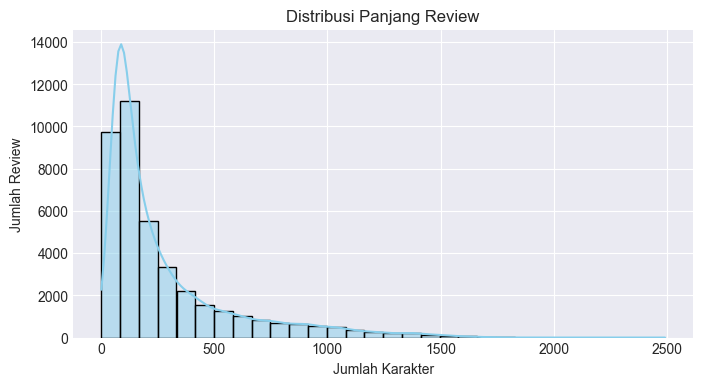

In [46]:
# Histogram panjang teks
plt.figure(figsize=(8, 4))
sns.histplot(df['review_length'], bins=30, kde=True, color='skyblue')
plt.title('Distribusi Panjang Review')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Jumlah Review')
plt.show()

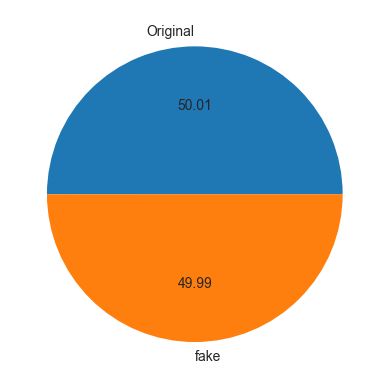

In [47]:
plt.pie(df['label'].value_counts(), labels=['Original', 'fake'],autopct="%0.2f")
plt.show()

In [48]:
contractions = {
    "ain't": "am not", "aren't": "are not", "can't": "cannot", "can't've": "cannot have",
    "'cause": "because", "could've": "could have", "couldn't": "could not",
    "couldn't've": "could not have", "didn't": "did not", "doesn't": "does not",
    "don't": "do not", "hadn't": "had not", "hadn't've": "had not have",
    "hasn't": "has not", "haven't": "have not", "he'd": "he would",
    "he'd've": "he would have", "he'll": "he will", "he'll've": "he will have",
    "he's": "he is", "how'd": "how did", "how'd'y": "how do you",
    "how'll": "how will", "how's": "how is", "i'd": "i would",
    "i'd've": "i would have", "i'll": "i will", "i'll've": "i will have",
    "i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
    "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have",
    "it's": "it is", "let's": "let us", "ma'am": "madam", "mayn't": "may not",
    "might've": "might have", "mightn't": "might not", "mightn't've": "might not have",
    "must've": "must have", "mustn't": "must not", "mustn't've": "must not have",
    "needn't": "need not", "needn't've": "need not have", "o'clock": "of the clock",
    "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not",
    "sha'n't": "shall not", "shan't've": "shall not have", "she'd": "she would",
    "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have",
    "she's": "she is", "should've": "should have", "shouldn't": "should not",
    "shouldn't've": "should not have", "so've": "so have", "so's": "so is",
    "that'd": "that would", "that'd've": "that would have", "that's": "that is",
    "there'd": "there would", "there'd've": "there would have", "there's": "there is",
    "these's": "these is", "they'd": "they would", "they'd've": "they would have",
    "they'll": "they will", "they'll've": "they will have", "they're": "they are",
    "they've": "they have", "to've": "to have", "wasn't": "was not",
    "we'd": "we would", "we'd've": "we would have", "we'll": "we will",
    "we'll've": "we will have", "we're": "we are", "we've": "we have",
    "weren't": "were not", "what'll": "what will", "what'll've": "what will have",
    "what're": "what are", "what's": "what is", "what've": "what have",
    "when's": "when is", "when've": "when have", "where'd": "where did",
    "where's": "where is", "where've": "where have", "who'll": "who will",
    "who'll've": "who will have", "who's": "who is", "who've": "who have",
    "why's": "why is", "why've": "why have", "will've": "will have",
    "won't": "will not", "won't've": "will not have", "would've": "would have",
    "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
    "y'all'd": "you all would", "y'all'd've": "you all would have",
    "y'all're": "you all are", "y'all've": "you all have", "you'd": "you would",
    "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
    "you're": "you are", "you've": "you have"
}

# Regex untuk mencocokkan kontraksi dengan word boundaries
# Word boundaries (\b) penting agar "he" tidak cocok dengan "here"
contractions_re = re.compile(r'\b(?:%s)\b' % '|'.join(re.escape(key) for key in contractions.keys()), re.IGNORECASE)

def replace_contractions(text):
    def replace(match):
        # Gunakan match.group(0) untuk mendapatkan string yang cocok, lalu lowercased
        return contractions[match.group(0).lower()]
    # re.IGNORECASE memastikan pencocokan tidak sensitif huruf besar/kecil
    return contractions_re.sub(replace, text)

In [49]:
negation_words = {"not", "no", "never"}
default_stopwords = set(stopwords.words('english'))
stopwords_keep_neg = default_stopwords - negation_words

lemmatizer = WordNetLemmatizer()

In [50]:
def preprocess_text(text):
    text = str(text).lower()
    text = replace_contractions(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.encode('ascii', 'ignore').decode('utf-8', errors='ignore')

    tokens = word_tokenize(text)
    cleaned_tokens = []

    for word in tokens:
        # Terapkan pembersihan tanda baca per karakter (seperti di kode baru)
        word = word.translate(str.maketrans('', '', string.punctuation))
        if not word:  # skip jika jadi string kosong
            continue
        # Terapkan filter isalpha (hanya huruf)
        if word.isalpha() and word not in stopwords_keep_neg:
            # Lemmatisasi tanpa POS (seperti kode lama)
            lemma = lemmatizer.lemmatize(word)
            cleaned_tokens.append(lemma)

    return ' '.join(cleaned_tokens)

In [51]:
df['clean_text'] = df['text'].astype(str).apply(preprocess_text)
df

,category,rating,label,text,review_length,clean_text
0,Home_&_Kitchen,5.0,0,"Love this! Well made, sturdy, and very comfor...",62,love well made sturdy comfortable love pretty
1,Home_&_Kitchen,5.0,0,"love it, a great upgrade from the original. I...",64,love great upgrade original mine couple year
2,Home_&_Kitchen,5.0,0,This pillow saved my back. I love the look and...,54,pillow saved back love look feel pillow
3,Home_&_Kitchen,1.0,0,"Missing information on how to use it, but it i...",64,missing information use great product price
4,Home_&_Kitchen,5.0,0,Very nice set. Good quality. We have had the s...,68,nice set good quality set two month not
...,...,...,...,...,...,...
40427,Clothing_Shoes_&_Jewelry,4.0,1,I had read some reviews saying that this bra r...,1348,read review saying bra ran small ordered two b...
40428,Clothing_Shoes_&_Jewelry,5.0,0,I wasn't sure exactly what it would be. It is ...,1015,not sure exactly would little large small size...
40429,Clothing_Shoes_&_Jewelry,2.0,1,"You can wear the hood by itself, wear it with ...",1640,wear hood wear hood wear jacket without hood s...
40430,Clothing_Shoes_&_Jewelry,1.0,0,I liked nothing about this dress. The only rea...,1017,liked nothing dress reason gave star ordered s...


In [52]:
print(df['text'].iloc[2])

This pillow saved my back. I love the look and feel of this pillow.


In [53]:
print(df['clean_text'].iloc[2])

pillow saved back love look feel pillow


In [54]:
keep_negation = True
stop_words = stopwords_keep_neg if keep_negation else default_stopwords

In [55]:
all_words = ' '.join(df['clean_text'])
tokens = [w.lower() for w in word_tokenize(all_words)]
remaining_stopwords = [w for w in tokens if w in stop_words]
print(f"Total Stopwords Tersisa: {len(remaining_stopwords)}")
print(Counter(remaining_stopwords).most_common(10))

Total Stopwords Tersisa: 467
[('m', 187), ('can', 42), ('he', 35), ('o', 27), ('there', 26), ('as', 24), ('being', 24), ('down', 16), ('s', 11), ('d', 10)]


In [57]:
#kata paling umum
clean_tokens = word_tokenize(all_words)
lemmas_counter = Counter(clean_tokens)
print("\n10 Kata Paling Umum (di clean_text, setelah lemmatisasi):")
print(lemmas_counter.most_common(10))


10 Kata Paling Umum (di clean_text, setelah lemmatisasi):
[('not', 34683), ('book', 17343), ('great', 16634), ('love', 15463), ('one', 14631), ('good', 14253), ('would', 11731), ('story', 10329), ('well', 10276), ('like', 10162)]


C:\Users\aqiel\AppData\Local\Temp\ipykernel_6644\1074566551.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=top_words_df, palette='viridis')


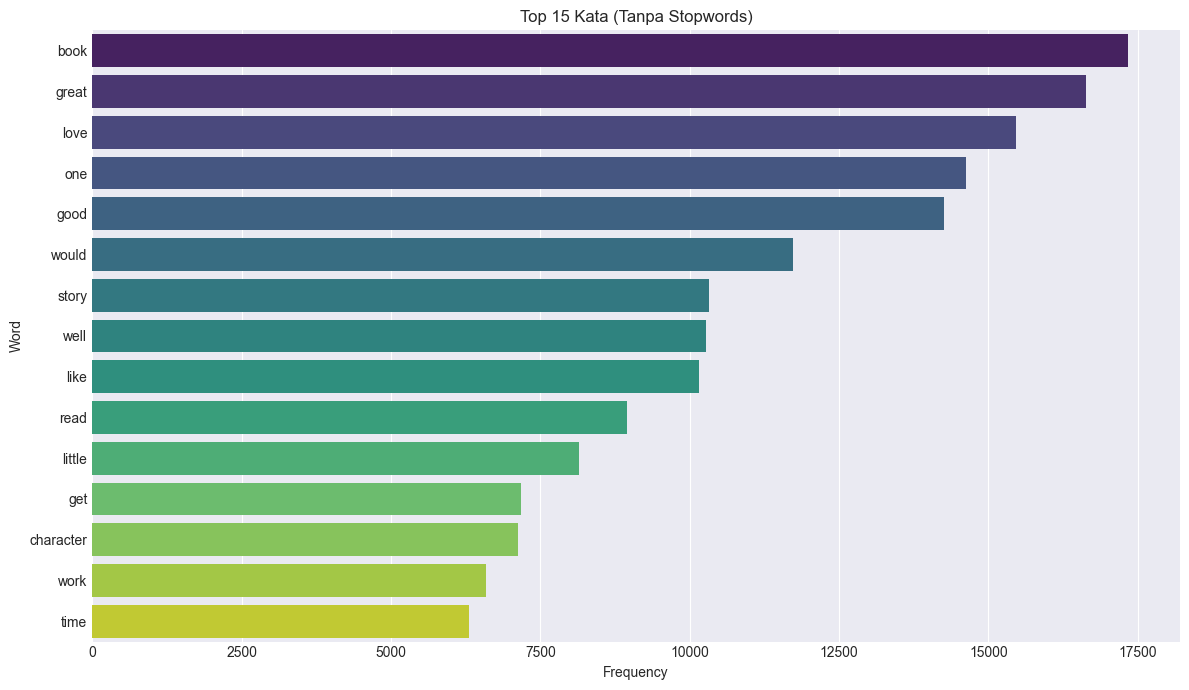

In [58]:
#negation_words = {"not", "no", "never"}
stop_words_v2 = set(stopwords.words('english'))
#custom_stopwords = set(stopwords.words('english')) - negation_words

all_clean_text = ' '.join(df['clean_text'].astype(str).tolist())
all_clean_text = all_clean_text.translate(str.maketrans('', '', string.punctuation))
words = all_clean_text.split()

# Buang stopwords
words_no_stop = [w for w in words if w not in stop_words_v2]

word_counts = Counter(words_no_stop)
n_top_words = 15

# Dapatkan N kata yang paling sering muncul (tanpa stopwords)
top_words = word_counts.most_common(n_top_words)
top_words_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(12, 7))
sns.barplot(x='Frequency', y='Word', data=top_words_df, palette='viridis')
plt.title(f'Top {n_top_words} Kata (Tanpa Stopwords)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

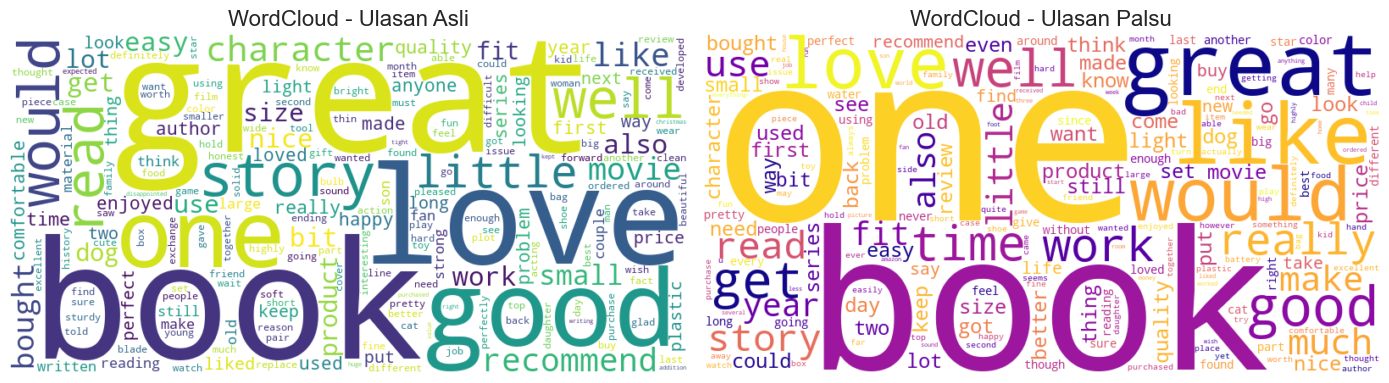

In [60]:
all_clean_text = ' '.join(df['clean_text'].astype(str).tolist())
words = all_clean_text.split()

# Buang stopwords
words_no_stop = [w for w in words if w not in stop_words_v2]

def top_words_label(df, label):
    text = ' '.join(df[df['label'] == label]['clean_text'])
    words = [w for w in text.split() if w not in stop_words_v2]
    return Counter(words)

# Gabung semua teks berdasarkan label tanpa stopwords
top_asli = top_words_label(df, 0)
top_palsu = top_words_label(df, 1)

wc_asli = dict(top_asli)
wc_palsu = dict(top_palsu)

# Fungsi untuk membuat word cloud
wordcloud_asli = WordCloud(width=800, height=400,
                           background_color='white',
                           colormap='viridis',
                           max_words=200).generate_from_frequencies(wc_asli)

wordcloud_palsu = WordCloud(width=800, height=400,
                            background_color='white',
                            colormap='plasma',
                            max_words=200).generate_from_frequencies(wc_palsu)

# Tampilkan side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 12))

axes[0].imshow(wordcloud_asli, interpolation='bilinear')
axes[0].set_title('WordCloud - Ulasan Asli', fontsize=16)
axes[0].axis("off")

axes[1].imshow(wordcloud_palsu, interpolation='bilinear')
axes[1].set_title('WordCloud - Ulasan Palsu', fontsize=16)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [61]:
df = df[['category', 'rating', 'label', 'clean_text']]
df

,category,rating,label,clean_text
0,Home_&_Kitchen,5.0,0,love well made sturdy comfortable love pretty
1,Home_&_Kitchen,5.0,0,love great upgrade original mine couple year
2,Home_&_Kitchen,5.0,0,pillow saved back love look feel pillow
3,Home_&_Kitchen,1.0,0,missing information use great product price
4,Home_&_Kitchen,5.0,0,nice set good quality set two month not
...,...,...,...,...
40427,Clothing_Shoes_&_Jewelry,4.0,1,read review saying bra ran small ordered two b...
40428,Clothing_Shoes_&_Jewelry,5.0,0,not sure exactly would little large small size...
40429,Clothing_Shoes_&_Jewelry,2.0,1,wear hood wear hood wear jacket without hood s...
40430,Clothing_Shoes_&_Jewelry,1.0,0,liked nothing dress reason gave star ordered s...


In [62]:
#save to new csv
df.to_csv('fake_reviews_cleaned.csv', index=False)